# 02 · EDA e mapas

Sazonalidade e comparação entre biomas, a partir de `data/processed/focos_mensais.csv`.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys; sys.path.append("..")
from src import features

In [7]:
monthly = pd.read_csv("../data/processed/focos_mensais.csv", parse_dates=["mes"])
monthly.head()

,bioma,mes,focos
0,Amazônia,2015-01-01,2042
1,Amazônia,2015-02-01,1047
2,Amazônia,2015-03-01,572
3,Amazônia,2015-04-01,762
4,Amazônia,2015-05-01,407


## Sazonalidade

In [8]:
sazonalidade = features.seasonal_average(monthly)
sazonalidade.head()

,bioma,mes_numero,focos
0,Amazônia,1,1627.454545
1,Amazônia,2,1106.818182
2,Amazônia,3,1390.272727
3,Amazônia,4,785.090909
4,Amazônia,5,1110.272727


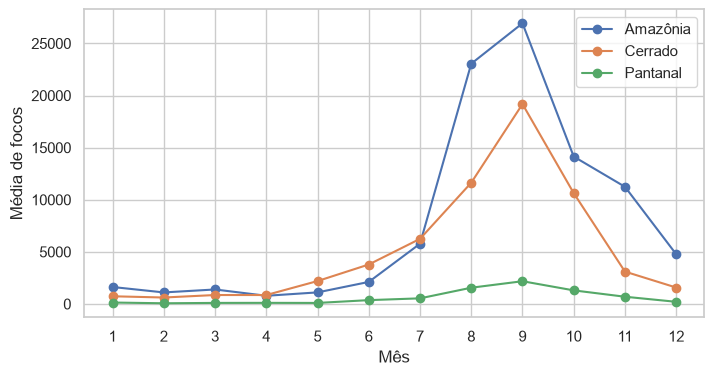

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

for bioma, grupo in sazonalidade.groupby("bioma"):
    ax.plot(grupo["mes_numero"], grupo["focos"], marker="o", label=bioma)

ax.set_xlabel("Mês")
ax.set_ylabel("Média de focos")
ax.set_xticks(range(1, 13))
ax.legend()

## Tendência ao longo do tempo

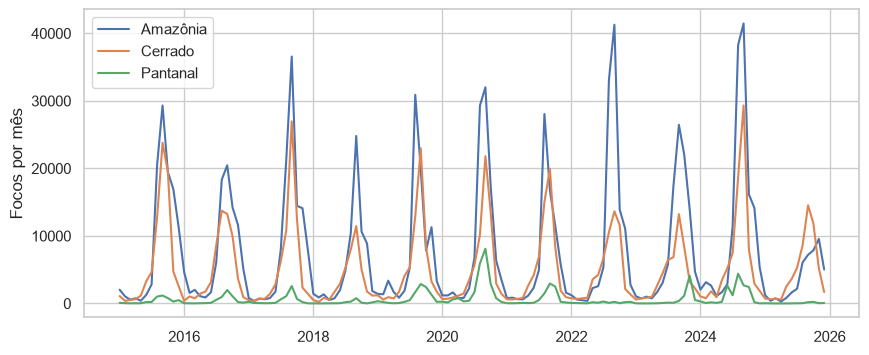

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

for bioma, grupo in monthly.groupby("bioma"):
    ax.plot(grupo["mes"], grupo["focos"], label=bioma)

ax.set_ylabel("Focos por mês")
ax.legend()

## Comparação ano a ano

In [11]:
total = monthly.groupby("mes")["focos"].sum().reset_index()
total["ano"] = total["mes"].dt.year
total["mes_numero"] = total["mes"].dt.month

In [12]:
pivot = total.pivot(index="ano", columns="mes_numero", values="focos")
pivot.head()

mes_numero,1,2,3,4,5,6,7,8,9,10,11,12
ano,,,,,,,,,,,,
2015,3233,1481,1128,1425,1617,4818,7704,34180,54302,39794,21948,14360
2016,5086,2636,2809,2558,2736,4943,15337,33036,35716,25268,15472,6181
2017,1548,828,1491,1352,2281,4710,14854,33151,66132,27519,16664,9444
2018,1988,1131,2215,1081,2529,4948,10198,18688,37055,15815,10664,3173
2019,2969,2153,4412,2488,2641,6207,11158,45496,45801,18641,15844,5265


Text(79.41216362847221, 0.5, 'Ano')

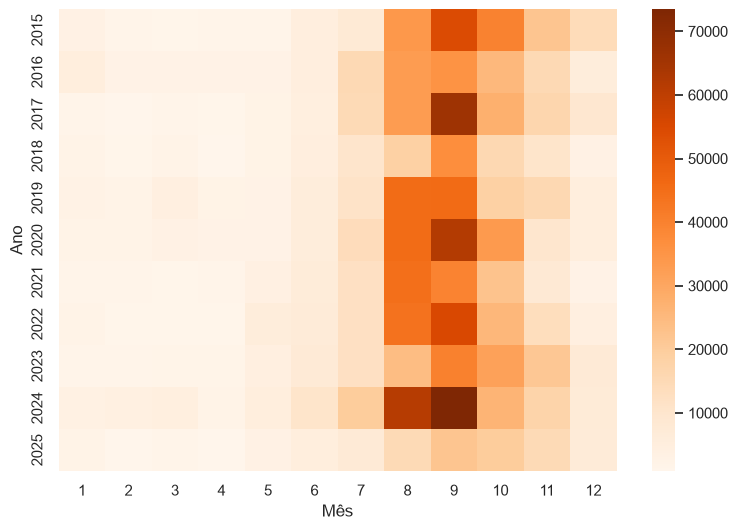

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, cmap="Oranges", ax=ax)
ax.set_xlabel("Mês")
ax.set_ylabel("Ano")

## Conclusões desta etapa

- **Sazonalidade:** os três biomas concentram os focos entre agosto e outubro, com pico em setembro. É o período mais seco do ano, quando a vegetação fica mais suscetível ao fogo.
- **Ranking entre biomas:** a Amazônia tem o maior volume de focos, seguida do Cerrado e depois do Pantanal, tanto na média sazonal quanto na série histórica. Como a Amazônia é também o maior bioma em área, isso não significa necessariamente que seja o mais afetado proporcionalmente; uma normalização por área é uma melhoria futura.
- **Anos críticos:** os picos de 2017, 2020 e, principalmente, 2024 se destacam na série e no heatmap. 2024 é o pico mais alto de toda a série na Amazônia, ultrapassando 40 mil focos num único mês.
- **Padrão consistente:** o heatmap mostra que a faixa de agosto a outubro se repete todo ano, o que indica um padrão sazonal forte e recorrente, e não eventos isolados.
- **Próximo passo:** investigar se o pico de 2024 está associado a condições climáticas (seca), o que exigiria trazer dados externos de precipitação numa fase futura do projeto.